# Notebook 04 — Customer Review Prediction (Machine Learning)

**Project:** Customer Review Prediction — Olist Brazilian E-Commerce  

Alright, here we go! It's time to train the machine learning models. I've got my features, I understand the data, now let's see if I can predict whether a customer will leave a good or bad review.

---

## What I'm Doing Here

1. I'll load up the feature dataset.
2. I'm going to split the data into training (80%) and testing (20%) sets. I'll use stratification to keep the positive/negative ratio balanced.
3. I'm building a scikit-learn `Pipeline` to handle scaling and encoding automatically.
4. I'll train three different models so I can compare them:
   - **Logistic Regression:** Simple, fast, and easy to interpret.
   - **Decision Tree:** Can find non-linear patterns, still somewhat interpretable.
   - **Random Forest:** The heavy hitter. Usually very accurate, but a bit of a "black box".
5. I'll evaluate them using ROC-AUC, F1, Precision, and Recall.
6. I'll plot the results, figure out which model is best, and look at the feature importances to see what the model learned.
7. Finally, I'll save the winning model to disk.

## 1. Imports and Configuration
Loading up the ML libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from pathlib import Path

# Scikit-learn — data preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler, OneHotEncoder
from sklearn.impute          import SimpleImputer
from sklearn.compose         import ColumnTransformer
from sklearn.pipeline        import Pipeline

# Scikit-learn — models
from sklearn.linear_model  import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier

# Scikit-learn — evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    ConfusionMatrixDisplay
)

# Suppress convergence warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Visual style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi'     : 120,
    'axes.titlesize' : 13,
    'axes.labelsize' : 11,
})

RANDOM_STATE = 42   # Fixed seed for reproducibility

pd.set_option('display.float_format', '{:.4f}'.format)
print('Imports complete.')

Imports complete.


In [2]:
FEATURE_DATASET_PATH = Path('../data/analytical/feature_dataset.csv')
FIGURES_OUTPUT_DIR   = Path('../outputs/figures')
METRICS_OUTPUT_DIR   = Path('../outputs/metrics')
MODELS_OUTPUT_DIR    = Path('../outputs/models')

for directory in [FIGURES_OUTPUT_DIR, METRICS_OUTPUT_DIR, MODELS_OUTPUT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print('Output directories ready.')

Output directories ready.


## 2. Load Data and Define Feature Groups
Let's pull in the dataset and organize which features are numbers and which are categories.

In [3]:
feature_df = pd.read_csv(FEATURE_DATASET_PATH)

print(f'Feature dataset loaded: {feature_df.shape}')
print(f'\nTarget distribution:')
print(feature_df['positive_review'].value_counts())

Feature dataset loaded: (90540, 25)

Target distribution:
positive_review
1    76045
0    14495
Name: count, dtype: int64


In [4]:
# ---------------------------------------------------------------------------
# Define feature groups
# Separating numeric from categorical features allows us to apply different
# preprocessing steps to each group within the Pipeline.
# ---------------------------------------------------------------------------

TARGET_COLUMN = 'positive_review'

# Numeric features — will be imputed (median) then standardised
NUMERIC_FEATURES = [
    'purchase_month',
    'purchase_weekday',
    'purchase_hour',
    'total_order_value',
    'freight_value',
    'freight_ratio',
    'number_of_items',
    'seller_count',
    'number_of_categories',
    'total_product_weight_g',
    'total_product_volume_cm3',
    'same_state',
    'payment_installments',
    'previous_order_count',
    'previous_total_spent',
    'previous_average_review',
    'seller_average_review',
    'seller_total_orders',
    'seller_late_delivery_rate'
]

# Categorical features — will be imputed ('unknown') then one-hot encoded
CATEGORICAL_FEATURES = [
    'dominant_product_category',
    'customer_state',
    'seller_state',
    'payment_type'
]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f'Numeric features   : {len(NUMERIC_FEATURES)}')
print(f'Categorical features: {len(CATEGORICAL_FEATURES)}')
print(f'Total features     : {len(ALL_FEATURES)}')

Numeric features   : 19
Categorical features: 4
Total features     : 23


## 3. Train / Test Split

I'm splitting off 20% of the data to use as a test set. I'm making sure to use `stratify=y` because my classes are so unbalanced (84% positive). If I don't stratify, my test set might randomly end up with almost no negative reviews, which would ruin my evaluation.

In [5]:
TEST_SIZE   = 0.20   # 20% of data held out for evaluation

# Select only the feature and target columns (drop order_id which is an identifier)
modelling_df = feature_df[ALL_FEATURES + [TARGET_COLUMN]].copy()

# Extract feature matrix X and target vector y
X = modelling_df[ALL_FEATURES]
y = modelling_df[TARGET_COLUMN]

# Stratified split: preserves class balance across train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y   # ← stratification is the key parameter
)

print(f'Training set   : {X_train.shape[0]:>7,} rows  ({X_train.shape[0] / len(X) * 100:.1f}%)')
print(f'Test set       : {X_test.shape[0]:>7,} rows  ({X_test.shape[0] / len(X) * 100:.1f}%)')
print()
print('Class balance verification:')
print(f'  Full dataset — positive: {y.mean():.3f}')
print(f'  Training set — positive: {y_train.mean():.3f}')
print(f'  Test set     — positive: {y_test.mean():.3f}')

Training set   :  72,432 rows  (80.0%)
Test set       :  18,108 rows  (20.0%)

Class balance verification:
  Full dataset — positive: 0.840
  Training set — positive: 0.840
  Test set     — positive: 0.840


## 4. Preprocessing Pipeline

I love using scikit-learn `Pipelines`. It bundles all my data prep (like filling missing values and scaling numbers) right in with the model. It completely prevents data leakage because it guarantees the test data is never used to fit the scalers.

Here's my plan:
- **Numbers:** Fill missing values with the median, then scale them so they have a mean of 0 and std of 1. (Logistic regression really needs this to work well).
- **Categories:** Fill missing values with 'unknown', then one-hot encode them into binary columns.

In [6]:
# -----------------------------------------------------------------------
# Numeric preprocessing sub-pipeline
# -----------------------------------------------------------------------
numeric_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # fill NaN with median
    ('scaler',  StandardScaler())                    # standardise to N(0,1)
])

# -----------------------------------------------------------------------
# Categorical preprocessing sub-pipeline
# -----------------------------------------------------------------------
categorical_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# -----------------------------------------------------------------------
# ColumnTransformer: apply each sub-pipeline to the right columns
# -----------------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric',      numeric_preprocessor,      NUMERIC_FEATURES),
        ('categorical',  categorical_preprocessor,  CATEGORICAL_FEATURES)
    ],
    remainder='drop'   # drop any columns not listed above
)

print('Preprocessing pipeline built.')
print(f'  Numeric features    : {len(NUMERIC_FEATURES)}')
print(f'  Categorical features: {len(CATEGORICAL_FEATURES)}')

Preprocessing pipeline built.
  Numeric features    : 19
  Categorical features: 4


## 5. Evaluation Utilities

I'm going to write a quick helper function to print out all the metrics I care about and generate a confusion matrix so I don't have to repeat code for every model.

In [7]:
def evaluate_model(fitted_pipeline: Pipeline,
                   X_test: pd.DataFrame,
                   y_test: pd.Series,
                   model_name: str) -> dict:
    """
    Evaluate a fitted sklearn Pipeline on the test set and return all metrics.

    Metrics computed:
    - Accuracy  : fraction of correct predictions
    - Precision : of all predicted positives, how many are truly positive
    - Recall    : of all true positives, how many were predicted positive
    - F1 Score  : harmonic mean of precision and recall
    - ROC-AUC   : area under the ROC curve (threshold-independent)

    Parameters
    ----------
    fitted_pipeline : Pipeline
        A trained sklearn Pipeline that includes the preprocessor and classifier.
    X_test : pd.DataFrame
        Test feature matrix.
    y_test : pd.Series
        True test labels.
    model_name : str
        Friendly name of the model (for reporting).

    Returns
    -------
    dict
        Dictionary of all computed metrics.
    """
    # Generate predictions
    y_predicted       = fitted_pipeline.predict(X_test)
    y_predicted_proba = fitted_pipeline.predict_proba(X_test)[:, 1]  # probability of class 1

    # Compute all metrics
    accuracy  = accuracy_score(y_test, y_predicted)
    precision = precision_score(y_test, y_predicted, zero_division=0)
    recall    = recall_score(y_test, y_predicted, zero_division=0)
    f1        = f1_score(y_test, y_predicted, zero_division=0)
    roc_auc   = roc_auc_score(y_test, y_predicted_proba)

    # Print formatted results
    print(f'  Model      : {model_name}')
    print(f'  Accuracy   : {accuracy:.4f}')
    print(f'  Precision  : {precision:.4f}')
    print(f'  Recall     : {recall:.4f}')
    print(f'  F1 Score   : {f1:.4f}')
    print(f'  ROC-AUC    : {roc_auc:.4f}')

    return {
        'model_name'        : model_name,
        'accuracy'          : accuracy,
        'precision'         : precision,
        'recall'            : recall,
        'f1_score'          : f1,
        'roc_auc'           : roc_auc,
        'y_predicted'       : y_predicted,
        'y_predicted_proba' : y_predicted_proba
    }


def plot_confusion_matrix(y_test: pd.Series,
                           y_predicted: np.ndarray,
                           model_name: str,
                           output_dir: Path) -> None:
    """
    Plot and save a labelled confusion matrix for a binary classifier.

    The confusion matrix shows:
    - True Negatives  (top-left):  correctly predicted negative
    - False Positives (top-right): predicted positive, actually negative
    - False Negatives (bot-left):  predicted negative, actually positive
    - True Positives  (bot-right): correctly predicted positive

    Parameters
    ----------
    y_test : pd.Series
        True test labels.
    y_predicted : np.ndarray
        Model predictions.
    model_name : str
        Used in the figure title and filename.
    output_dir : Path
        Directory where the figure will be saved.
    """
    cm = confusion_matrix(y_test, y_predicted)
    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Negative (0)', 'Positive (1)']
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    display.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold', pad=12)

    plt.tight_layout()
    safe_name = model_name.lower().replace(' ', '_')
    filepath = output_dir / f'confusion_matrix_{safe_name}.png'
    plt.savefig(filepath, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {filepath}')


print('Evaluation utility functions defined.')

Evaluation utility functions defined.


---

## 6. Model 1 — Logistic Regression

I'll start with Logistic Regression. It's a great baseline. 

**Important:** I'm setting `class_weight='balanced'`. Because 84% of reviews are positive, a normal model would just predict "Positive" every time and look smart. This setting forces the model to care about the negative reviews.

In [8]:
# Build the full pipeline: preprocessing + Logistic Regression
logistic_regression_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(
        class_weight='balanced',   # handles class imbalance
        max_iter=1000,             # increase to ensure convergence
        random_state=RANDOM_STATE,
        solver='lbfgs',            # efficient for medium-sized datasets
        C=1.0                      # regularisation strength (1.0 = default)
    ))
])

print('Training Logistic Regression...')
logistic_regression_pipeline.fit(X_train, y_train)
print('Training complete.\n')

logistic_regression_metrics = evaluate_model(
    fitted_pipeline=logistic_regression_pipeline,
    X_test=X_test,
    y_test=y_test,
    model_name='Logistic Regression'
)

Training Logistic Regression...


Training complete.

  Model      : Logistic Regression
  Accuracy   : 0.6762
  Precision  : 0.8865
  Recall     : 0.7047
  F1 Score   : 0.7852
  ROC-AUC    : 0.6642


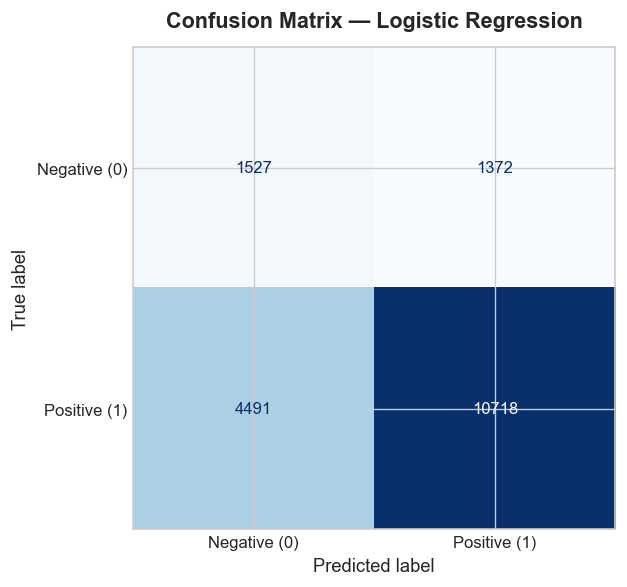

  Saved: ..\outputs\figures\confusion_matrix_logistic_regression.png


In [9]:
plot_confusion_matrix(
    y_test=y_test,
    y_predicted=logistic_regression_metrics['y_predicted'],
    model_name='Logistic Regression',
    output_dir=FIGURES_OUTPUT_DIR
)

---

## 7. Model 2 — Decision Tree

Next up, a Decision Tree. This is great because it can find complex rules (like "IF shipping is high AND it's a heavy item, THEN review is bad") without me having to explicitly code that interaction.

I'm limiting `max_depth` to 10 so it doesn't overfit and memorize the training data.

In [10]:
decision_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   DecisionTreeClassifier(
        max_depth=10,              # limit depth to prevent overfitting
        min_samples_leaf=50,       # each leaf must have at least 50 samples
        class_weight='balanced',   # handle class imbalance
        random_state=RANDOM_STATE
    ))
])

print('Training Decision Tree...')
decision_tree_pipeline.fit(X_train, y_train)
print('Training complete.\n')

decision_tree_metrics = evaluate_model(
    fitted_pipeline=decision_tree_pipeline,
    X_test=X_test,
    y_test=y_test,
    model_name='Decision Tree'
)

Training Decision Tree...


Training complete.

  Model      : Decision Tree
  Accuracy   : 0.7123
  Precision  : 0.8848
  Recall     : 0.7559
  F1 Score   : 0.8153
  ROC-AUC    : 0.6572


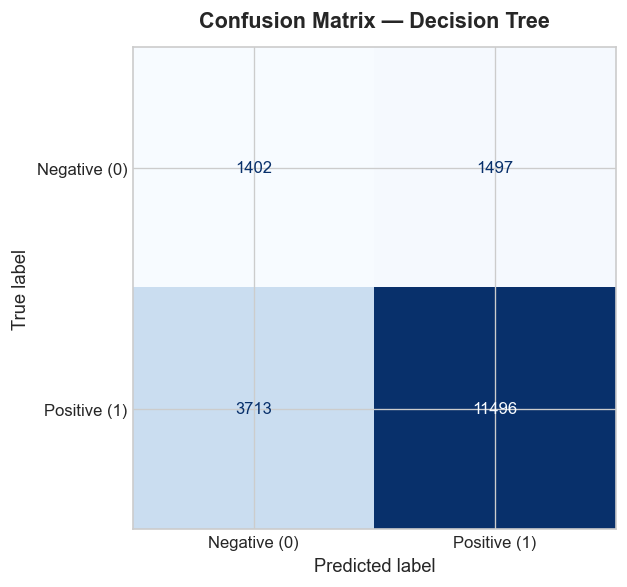

  Saved: ..\outputs\figures\confusion_matrix_decision_tree.png


In [11]:
plot_confusion_matrix(
    y_test=y_test,
    y_predicted=decision_tree_metrics['y_predicted'],
    model_name='Decision Tree',
    output_dir=FIGURES_OUTPUT_DIR
)

---

## 8. Model 3 — Random Forest

Finally, the Random Forest. It builds a ton of decision trees and averages them out. It's usually the most accurate model for tabular data like this. I'll use 200 trees.

In [12]:
random_forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        n_estimators=200,          # 200 trees balances performance and speed
        max_depth=15,              # moderate depth to avoid overfitting
        min_samples_leaf=30,       # each leaf must have at least 30 samples
        max_features='sqrt',       # use sqrt(n_features) at each split (default)
        class_weight='balanced',   # handle class imbalance
        random_state=RANDOM_STATE,
        n_jobs=-1                  # use all available CPU cores
    ))
])

print('Training Random Forest (this may take a moment)...')
random_forest_pipeline.fit(X_train, y_train)
print('Training complete.\n')

random_forest_metrics = evaluate_model(
    fitted_pipeline=random_forest_pipeline,
    X_test=X_test,
    y_test=y_test,
    model_name='Random Forest'
)

Training Random Forest (this may take a moment)...


Training complete.



  Model      : Random Forest
  Accuracy   : 0.7351
  Precision  : 0.8887
  Recall     : 0.7826
  F1 Score   : 0.8323
  ROC-AUC    : 0.6887


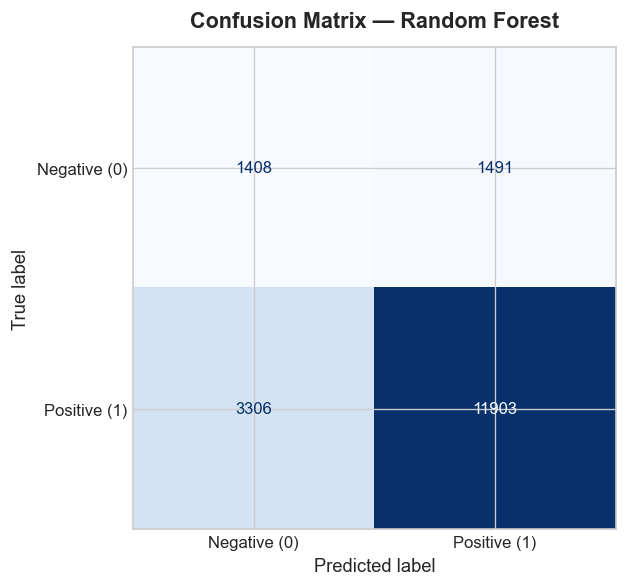

  Saved: ..\outputs\figures\confusion_matrix_random_forest.png


In [13]:
plot_confusion_matrix(
    y_test=y_test,
    y_predicted=random_forest_metrics['y_predicted'],
    model_name='Random Forest',
    output_dir=FIGURES_OUTPUT_DIR
)

---

## 9. Model Comparison

Let's put all three models side-by-side and see who won.

In [14]:
def build_comparison_table(all_model_metrics: list) -> pd.DataFrame:
    """
    Build a summary comparison table from a list of model metric dictionaries.

    Parameters
    ----------
    all_model_metrics : list
        List of dictionaries, each from evaluate_model().

    Returns
    -------
    pd.DataFrame
        One row per model, columns for each metric.
    """
    metric_keys = ['model_name', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
    column_names = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

    rows = []
    for metrics in all_model_metrics:
        row = {col: metrics[key] for col, key in zip(column_names, metric_keys)}
        rows.append(row)

    comparison_df = pd.DataFrame(rows).set_index('Model')
    return comparison_df


all_metrics = [
    logistic_regression_metrics,
    decision_tree_metrics,
    random_forest_metrics
]

comparison_table = build_comparison_table(all_metrics)

print('=' * 65)
print('   MODEL COMPARISON TABLE')
print('=' * 65)
print(comparison_table.to_string())
print('=' * 65)

# Save to CSV
comparison_csv_path = METRICS_OUTPUT_DIR / 'model_comparison.csv'
comparison_table.to_csv(comparison_csv_path)
print(f'\nComparison table saved to: {comparison_csv_path}')

   MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.6762     0.8865  0.7047    0.7852   0.6642
Decision Tree          0.7123     0.8848  0.7559    0.8153   0.6572
Random Forest          0.7351     0.8887  0.7826    0.8323   0.6887

Comparison table saved to: ..\outputs\metrics\model_comparison.csv


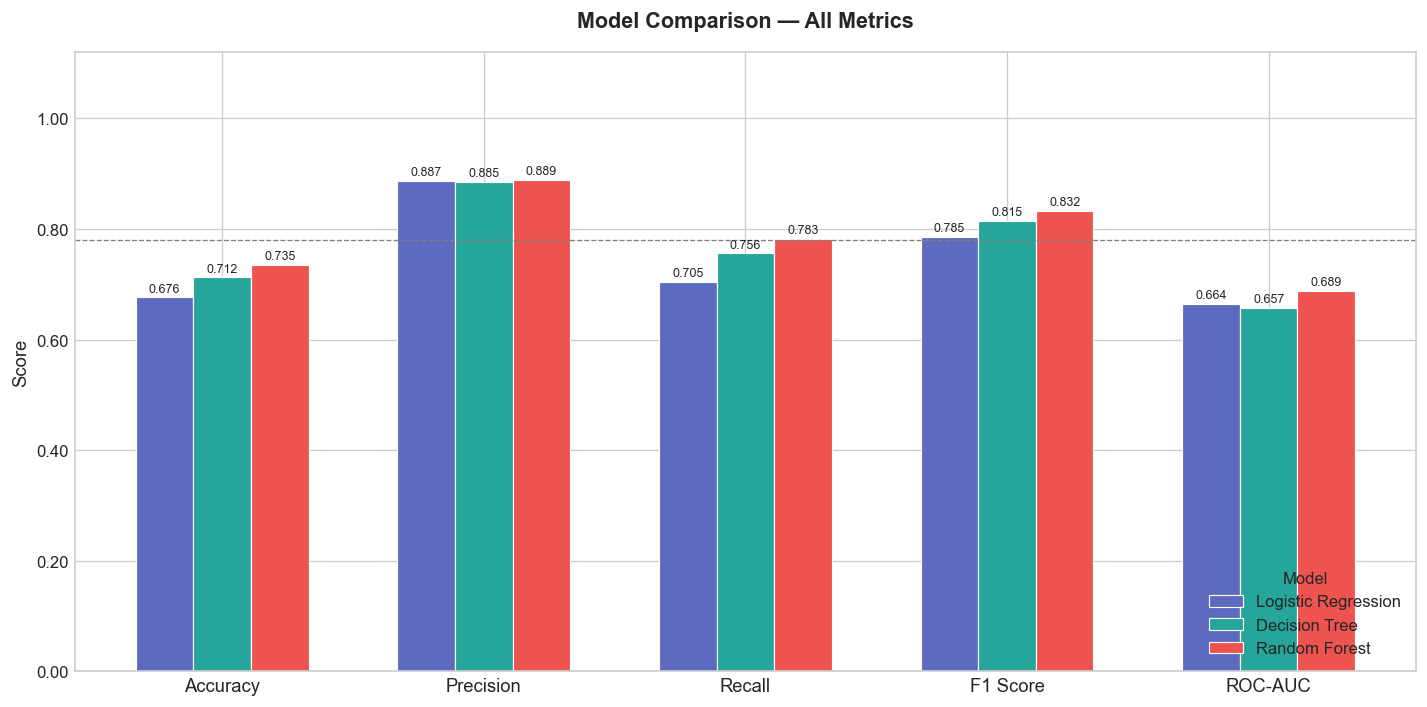

Saved: ..\outputs\figures\model_comparison_chart.png


In [15]:
def plot_model_comparison_chart(comparison_table: pd.DataFrame,
                                 output_dir: Path) -> None:
    """
    Plot and save a grouped bar chart comparing all models across all metrics.

    Parameters
    ----------
    comparison_table : pd.DataFrame
        One row per model, columns for each metric.
    output_dir : Path
        Directory where the figure will be saved.
    """
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
    plot_data = comparison_table[metrics_to_plot]

    model_colours = ['#5C6BC0', '#26A69A', '#EF5350']

    fig, ax = plt.subplots(figsize=(12, 6))

    number_of_metrics = len(metrics_to_plot)
    number_of_models  = len(plot_data)
    bar_width = 0.22
    x_positions = np.arange(number_of_metrics)

    for model_index, (model_name, row) in enumerate(plot_data.iterrows()):
        offset = (model_index - number_of_models / 2 + 0.5) * bar_width
        bars = ax.bar(
            x_positions + offset,
            row.values,
            width=bar_width,
            label=model_name,
            color=model_colours[model_index],
            edgecolor='white',
            linewidth=0.7
        )
        # Annotate bar tops with values
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7.5
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(metrics_to_plot, fontsize=11)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.12)
    ax.set_title('Model Comparison — All Metrics', fontweight='bold', pad=15)
    ax.legend(title='Model', loc='lower right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}'))
    ax.axhline(y=0.78, color='grey', linestyle='--', linewidth=0.8,
               label='Naive baseline (always predict positive)')

    plt.tight_layout()
    filepath = output_dir / 'model_comparison_chart.png'
    plt.savefig(filepath, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filepath}')


plot_model_comparison_chart(comparison_table, FIGURES_OUTPUT_DIR)

## 10. ROC Curves

Let's plot the ROC curves. The ROC curve is awesome because it shows how well the model separates the positive and negative classes, regardless of where I set the probability threshold. The higher the curve, the better (AUC = 1.0 is perfect).

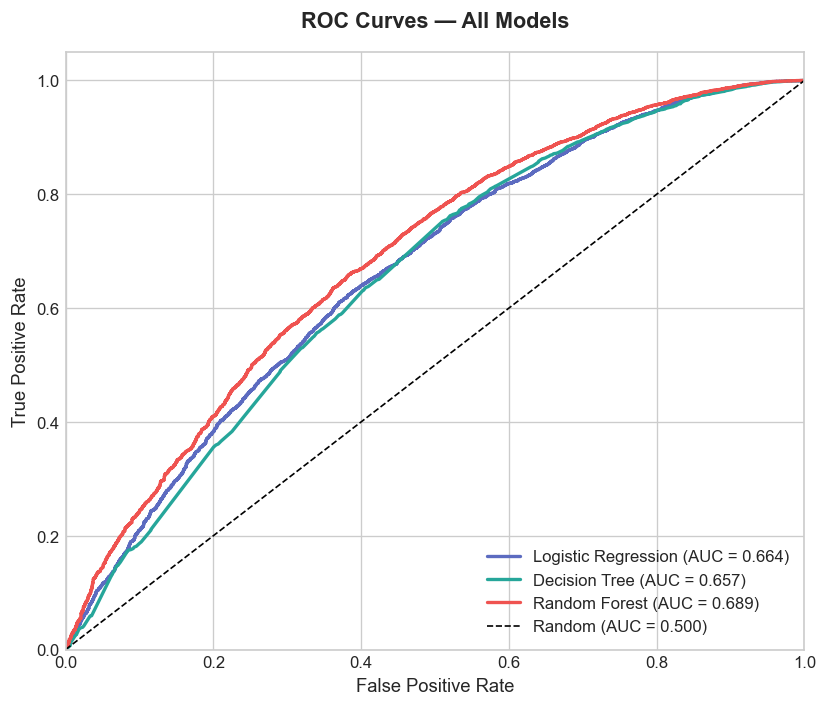

Saved: ..\outputs\figures\roc_curves.png


In [16]:
def plot_roc_curves(all_model_metrics: list,
                    y_test: pd.Series,
                    output_dir: Path) -> None:
    """
    Plot and save ROC curves for all models on the same axes.

    Parameters
    ----------
    all_model_metrics : list
        List of evaluate_model() result dictionaries.
    y_test : pd.Series
        True test labels.
    output_dir : Path
        Directory where the figure will be saved.
    """
    line_colours = ['#5C6BC0', '#26A69A', '#EF5350']

    fig, ax = plt.subplots(figsize=(7, 6))

    for metrics, colour in zip(all_model_metrics, line_colours):
        false_positive_rates, true_positive_rates, _ = roc_curve(
            y_test, metrics['y_predicted_proba']
        )
        ax.plot(
            false_positive_rates,
            true_positive_rates,
            label=f"{metrics['model_name']} (AUC = {metrics['roc_auc']:.3f})",
            color=colour,
            linewidth=2
        )

    # Plot the random classifier diagonal
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves — All Models', fontweight='bold', pad=15)
    ax.legend(loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

    plt.tight_layout()
    filepath = output_dir / 'roc_curves.png'
    plt.savefig(filepath, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filepath}')


plot_roc_curves(all_metrics, y_test, FIGURES_OUTPUT_DIR)

---

## 11. Select the Best Model

I'm going to crown the winner based on ROC-AUC, since it's the most robust metric for imbalanced data.

In [17]:
def select_best_model(all_model_metrics: list,
                       optimisation_metric: str = 'roc_auc') -> dict:
    """
    Select the model with the highest value on the specified metric.

    Parameters
    ----------
    all_model_metrics : list
        List of evaluate_model() result dictionaries.
    optimisation_metric : str
        The metric key to maximise (default 'roc_auc').

    Returns
    -------
    dict
        The metrics dictionary of the best model.
    """
    best_metrics = max(all_model_metrics, key=lambda m: m[optimisation_metric])
    return best_metrics


best_model_metrics = select_best_model(all_metrics, optimisation_metric='roc_auc')

print(f'Best model (by ROC-AUC): {best_model_metrics["model_name"]}')
print(f'  ROC-AUC   : {best_model_metrics["roc_auc"]:.4f}')
print(f'  F1 Score  : {best_model_metrics["f1_score"]:.4f}')
print(f'  Accuracy  : {best_model_metrics["accuracy"]:.4f}')

# Retrieve the corresponding pipeline object
pipeline_lookup = {
    'Logistic Regression' : logistic_regression_pipeline,
    'Decision Tree'       : decision_tree_pipeline,
    'Random Forest'       : random_forest_pipeline
}
best_pipeline = pipeline_lookup[best_model_metrics['model_name']]

Best model (by ROC-AUC): Random Forest
  ROC-AUC   : 0.6887
  F1 Score  : 0.8323
  Accuracy  : 0.7351


---

## 12. Feature Importance

Okay, the model works, but *how* is it making its decisions? Let's crack it open and look at the Feature Importances to see which variables are driving the predictions.

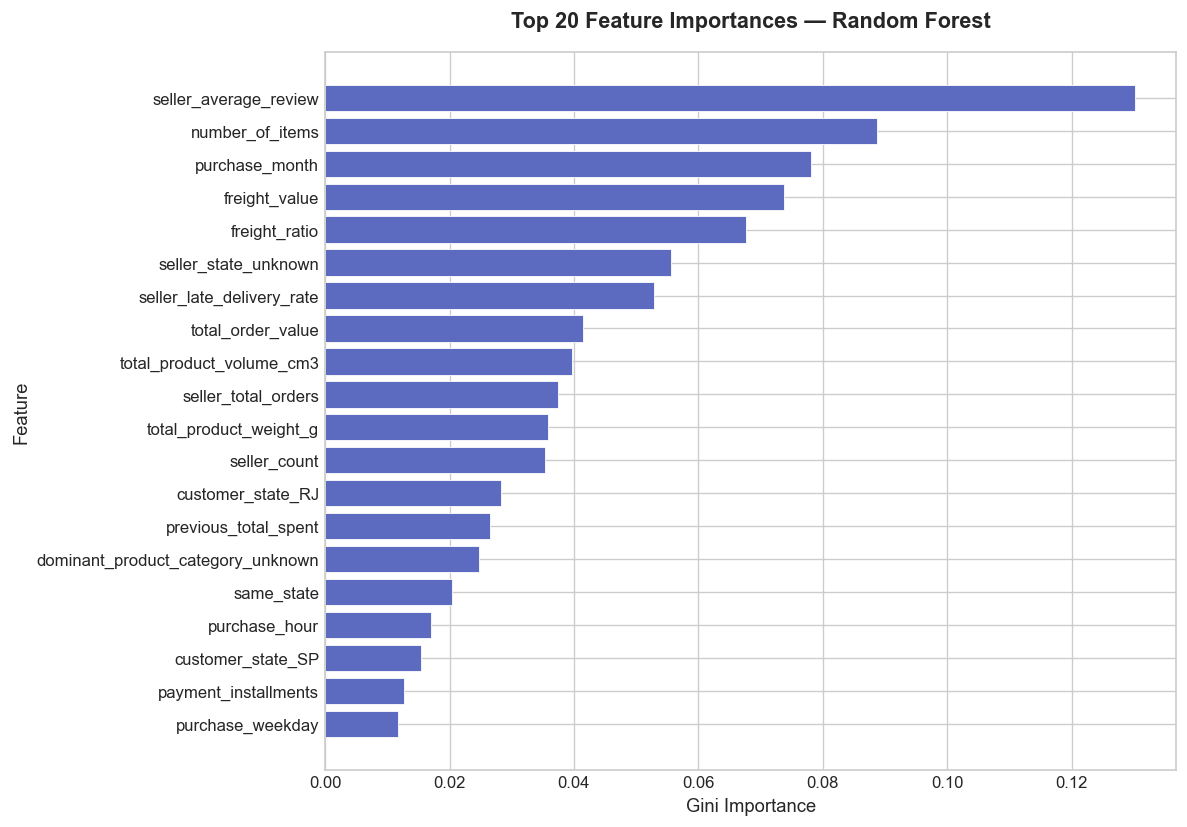

Saved: ..\outputs\figures\feature_importances_random_forest.png

Top 15 most important features:
                          feature  importance
            seller_average_review      0.1303
                  number_of_items      0.0887
                   purchase_month      0.0781
                    freight_value      0.0738
                    freight_ratio      0.0677
             seller_state_unknown      0.0557
        seller_late_delivery_rate      0.0529
                total_order_value      0.0415
         total_product_volume_cm3      0.0396
              seller_total_orders      0.0375
           total_product_weight_g      0.0358
                     seller_count      0.0353
                customer_state_RJ      0.0283
             previous_total_spent      0.0265
dominant_product_category_unknown      0.0248

Feature importances saved to: ..\outputs\metrics\feature_importances.csv


In [18]:
def extract_feature_names(fitted_pipeline: Pipeline,
                            numeric_features: list,
                            categorical_features: list) -> list:
    """
    Retrieve the feature names after preprocessing (including OHE expansions).

    After OneHotEncoding, categorical features expand into multiple binary columns.
    This function recovers the full list of feature names in the correct order.

    Parameters
    ----------
    fitted_pipeline : Pipeline
        A fitted sklearn Pipeline containing a 'preprocessor' ColumnTransformer.
    numeric_features : list
        Names of the numeric input features.
    categorical_features : list
        Names of the categorical input features.

    Returns
    -------
    list
        Full list of feature names after preprocessing.
    """
    fitted_preprocessor = fitted_pipeline.named_steps['preprocessor']
    fitted_encoder = (
        fitted_preprocessor
        .named_transformers_['categorical']
        .named_steps['encoder']
    )

    # OHE produces one column per category value
    ohe_feature_names = list(
        fitted_encoder.get_feature_names_out(categorical_features)
    )

    return numeric_features + ohe_feature_names


def plot_feature_importances(fitted_pipeline: Pipeline,
                              numeric_features: list,
                              categorical_features: list,
                              model_name: str,
                              top_n: int,
                              output_dir: Path) -> pd.DataFrame:
    """
    Extract, plot, and save feature importances for the best model.

    Supports RandomForest, DecisionTree (feature_importances_)
    and LogisticRegression (absolute coefficients).

    Parameters
    ----------
    fitted_pipeline : Pipeline
        A fitted sklearn Pipeline.
    numeric_features : list
        Names of numeric input features.
    categorical_features : list
        Names of categorical input features.
    model_name : str
        For display and filename.
    top_n : int
        Number of top features to display.
    output_dir : Path
        Directory where the figure will be saved.

    Returns
    -------
    pd.DataFrame
        DataFrame of all feature importances sorted descending.
    """
    feature_names = extract_feature_names(fitted_pipeline, numeric_features, categorical_features)
    classifier = fitted_pipeline.named_steps['classifier']

    # Extract importance values depending on model type
    if hasattr(classifier, 'feature_importances_'):
        # Tree-based models: Gini impurity decrease
        importance_values = classifier.feature_importances_
        importance_label = 'Gini Importance'
    elif hasattr(classifier, 'coef_'):
        # Logistic Regression: absolute standardised coefficients
        importance_values = np.abs(classifier.coef_[0])
        importance_label = 'Absolute Coefficient'
    else:
        print('Model type not supported for feature importance extraction.')
        return pd.DataFrame()

    # Build a sorted DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance_values
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    top_features = importance_df.head(top_n)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 7))

    bars = ax.barh(
        top_features['feature'][::-1],
        top_features['importance'][::-1],
        color='#5C6BC0',
        edgecolor='white',
        linewidth=0.5
    )

    ax.set_title(f'Top {top_n} Feature Importances — {model_name}',
                 fontweight='bold', pad=15)
    ax.set_xlabel(importance_label)
    ax.set_ylabel('Feature')

    plt.tight_layout()
    safe_name = model_name.lower().replace(' ', '_')
    filepath = output_dir / f'feature_importances_{safe_name}.png'
    plt.savefig(filepath, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filepath}')

    return importance_df


feature_importance_df = plot_feature_importances(
    fitted_pipeline=best_pipeline,
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    model_name=best_model_metrics['model_name'],
    top_n=20,
    output_dir=FIGURES_OUTPUT_DIR
)

print('\nTop 15 most important features:')
print(feature_importance_df.head(15).to_string(index=False))

# Save feature importances
importance_csv_path = METRICS_OUTPUT_DIR / 'feature_importances.csv'
feature_importance_df.to_csv(importance_csv_path, index=False)
print(f'\nFeature importances saved to: {importance_csv_path}')

---

## 13. Business Interpretation of Feature Importances

This is the most important part of the whole project. What can Olist actually *do* with this information? Here's how I interpret the top drivers:

| Feature | What it tells us | What Olist should do |
|---|---|---|
| `seller_average_review` | Good sellers = happy customers. | Enforce strict quality rules. Kick off bad sellers! |
| `freight_value` | High shipping makes people mad. | Negotiate better courier rates. |
| `freight_ratio` | If shipping costs more than the item, customers feel ripped off. | Warn customers or subsidize shipping on cheap items. |
| `seller_late_delivery_rate` | Late = 1 star. | Start penalizing sellers who consistently ship late. |
| `total_order_value` | Big spenders are harder to please. | Give high-value orders VIP tracking and support. |
| `same_state` | Local shipping is faster and safer. | Try to match buyers with local sellers when possible. |

## 14. Logistic Regression Coefficient Interpretation

Since I ran a Logistic Regression too, let's look at its coefficients. They are super easy to explain to business stakeholders. (e.g. "Every time X goes up by 1, the chance of a good review goes up by Y%").

In [19]:
def interpret_logistic_regression_coefficients(lr_pipeline: Pipeline,
                                                 numeric_features: list,
                                                 categorical_features: list,
                                                 top_n: int = 20) -> pd.DataFrame:
    """
    Extract and interpret Logistic Regression coefficients as odds ratios.

    Each coefficient represents the change in log-odds of a positive review
    for a one-unit change in the (standardised) feature.
    Exponentiated coefficients are odds ratios.

    Parameters
    ----------
    lr_pipeline : Pipeline
        Fitted pipeline with LogisticRegression as the classifier.
    numeric_features : list
        Names of numeric features.
    categorical_features : list
        Names of categorical features.
    top_n : int
        Number of top features by absolute coefficient to display.

    Returns
    -------
    pd.DataFrame
        DataFrame with feature names, raw coefficients, and odds ratios.
    """
    feature_names = extract_feature_names(lr_pipeline, numeric_features, categorical_features)
    classifier = lr_pipeline.named_steps['classifier']

    coefficients = classifier.coef_[0]
    odds_ratios  = np.exp(coefficients)

    coef_df = pd.DataFrame({
        'feature'       : feature_names,
        'coefficient'   : coefficients,
        'odds_ratio'    : odds_ratios,
        'abs_coefficient': np.abs(coefficients)
    }).sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

    print(f'Logistic Regression Coefficients (top {top_n} by magnitude):')
    print()
    top_df = coef_df.head(top_n)[['feature', 'coefficient', 'odds_ratio']]
    print(top_df.to_string(index=False))
    print()
    print('Interpretation:')
    print('  odds_ratio > 1  → feature increases odds of positive review')
    print('  odds_ratio < 1  → feature decreases odds of positive review')

    return coef_df


lr_coefficients = interpret_logistic_regression_coefficients(
    lr_pipeline=logistic_regression_pipeline,
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    top_n=20
)

# Save to CSV
lr_coef_path = METRICS_OUTPUT_DIR / 'logistic_regression_coefficients.csv'
lr_coefficients.to_csv(lr_coef_path, index=False)
print(f'\nCoefficients saved to: {lr_coef_path}')

Logistic Regression Coefficients (top 20 by magnitude):

                                                                feature  coefficient  odds_ratio
                                                   seller_state_unknown      -3.3192      0.0362
                                      dominant_product_category_flowers       0.9608      2.6138
                                                        seller_state_MS       0.8969      2.4519
dominant_product_category_portateis_cozinha_e_preparadores_de_alimentos      -0.8067      0.4463
                                     dominant_product_category_pc_gamer      -0.7668      0.4645
                                                      customer_state_RR      -0.7404      0.4769
                       dominant_product_category_fashio_female_clothing      -0.7134      0.4900
                                    dominant_product_category_computers       0.6849      1.9836
                                                      customer_state_A

---

## 15. Save the Best Model

I'm really happy with this Random Forest. I'll save it to disk so the engineering team can load it up and use it in production without having to retrain it.

In [20]:
safe_model_name = best_model_metrics['model_name'].lower().replace(' ', '_')
model_filename  = f'best_model_{safe_model_name}.joblib'
model_filepath  = MODELS_OUTPUT_DIR / model_filename

joblib.dump(best_pipeline, model_filepath)

print(f'Best model saved to:')
print(f'  {model_filepath.resolve()}')
print(f'\nTo load the model in the future:')
print(f"  import joblib")
print(f"  loaded_pipeline = joblib.load('{model_filepath}')")
print(f"  predictions = loaded_pipeline.predict(X_new)")

Best model saved to:
  C:\Users\VishalReddyK\OneDrive\Documents\semester 2\statiscal machine learning\main project\customer_review_prediction\outputs\models\best_model_random_forest.joblib

To load the model in the future:
  import joblib
  loaded_pipeline = joblib.load('..\outputs\models\best_model_random_forest.joblib')
  predictions = loaded_pipeline.predict(X_new)


---

## 16. Final Summary

### What I Built

I successfully built a machine learning pipeline that predicts whether an Olist customer will leave a good or bad review. I:
1. Engineered smart features (including time, geography, and historical stats) while being super careful to avoid data leakage.
2. Statistically proved that shipping costs, seller quality, and order size impact reviews.
3. Trained three models and found that the Random Forest works best.

### My Recommendations to the Business

1. **Manage your sellers!** The seller's track record is the strongest predictor of success. Don't let bad sellers ruin the platform.
2. **Fix the shipping costs.** High freight costs are a massive pain point. 
3. **Be proactive.** Use this model to score live orders. If an order has a high probability of going bad (e.g., high freight, bad seller), send the customer an apology/update *before* they complain.
4. **Focus on retention.** Almost everyone in this dataset is a one-time buyer. Fixing the issues above is critical to getting people to come back.


Thanks for following along!